## 1. Introduction and Objective
BETA BANK is facing a rising customer churn rate, and since it is cheaper to retain existing customers than to attract new ones, the objective here is to build a machine learning model capable of predicting whether a customer will leave the bank or not.

I will use historical data on customer behavior and contract terminations. The final model must achieve an F1-score of at least 0.59 on the test set, and its AUC-ROC metric must be evaluated and compared.

To ensure the best possible performance, I will use class balancing techniques and advanced hyperparameter optimization with `RandomizedSearchCV`.

I will begin by importing the necessary libraries.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.utils import shuffle

# The import statement below will suppress deprecation warnings to keep everything "cleaner"import warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Data Preparation
In this step, I will load the data, remove columns that do not contribute to the model’s learning, and handle missing values. I will also apply one-hot encoding to categorical variables and scaling to numerical variables.

In [16]:
df = pd.read_csv('../data/Churn.csv')

display(df.head())
df.info()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.2 MB


The `Tenure` column contains null values. Since this column represents the length of time a customer has been with the company, I will fill it with the median value so as not to skew the distribution.

Next, I will remove the columns that are irrelevant to the predictive model, which are `RowNumber`, `CustomerId`, and `Surname`.

In [17]:
df['Tenure'].fillna(df['Tenure'].median(), inplace=True)

cols_to_remove = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(cols_to_remove, axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           9091 non-null   float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 966.1 KB


Now, for ONE-HOT ENCODING, I will use `drop_first=True` to avoid pitfalls associated with dummy variables

In [18]:
df = pd.get_dummies(df, drop_first=True)
display(df.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False


## 3. Data Splitting and Shuffling
I will split the data into features (x) and target (y). Then, I will divide the dataset into two parts: training (80%) and testing (20%). I will use cross-validation, so a static validation set will not be necessary

In [19]:
x = df.drop('Exited', axis=1)
y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=54321, stratify=y)

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()

scaler.fit(x_train[numeric_cols])
x_train[numeric_cols] = scaler.transform(x_train[numeric_cols])
x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])

print("Size of x_train:", x_train.shape)
print("Size of x_test", x_test.shape)


Size of x_train: (8000, 11)
Size of x_test (2000, 11)


## 4. Examining Imbalance and Training the Base Model
Now, I will examine the ratio between the classes (churned customers vs. retained customers). I will train a base model (RandomForest) without correcting for imbalance to establish a baseline.

In [ ]:
print("Class distribution in Target:")
print(y.value_counts(normalize=True))

#The initial model
model_base = RandomForestClassifier(random_state=54321)
model_base.fit(x_train, y_train)

#Predictions and metrics
preds_base = model_base.predict(x_test)
probs_base = model_base.predict_proba(x_test)[:, 1]

f1_base = f1_score(y_test, preds_base)
roc_auc_base = roc_auc_score(y_test, probs_base)

print("F1-score (base)", f1_base)
print("AUC-ROC (base)", roc_auc_base)

Class distribution in Target:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64
F1-score (base) 0.5683229813664596
AUC-ROC (base) 0.8427395037564529


Customers who did not leave account for nearly 80% of the data. Due to this imbalance, the base model tends to favor the majority class, resulting in an F1 score that can and should be improved. The AUC-ROC indicates that the model has some ability to distinguish between classes, but intervention is needed here

## 5. Improving Quality: Addressing Imbalance
To address this, I will test two approaches:
1. Class Weight: Where I will penalize errors in the minority class more severely
2. Upsampling: Where I will artificially increase the number of instances in the minority class within the training set

In [21]:
# CLASS WEIGHT APPROACH
model_weight = RandomForestClassifier(class_weight='balanced', random_state=54321)
model_weight.fit(x_train, y_train)
preds_weight = model_weight.predict(x_test)
print("F1-score (Class Weight)", f1_score(y_test, preds_weight))

# UPSAMPLING APPROACH
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=54321)
    return features_upsampled, target_upsampled

# In the previous code, we saw that class 0 is about four times larger than class 1, so I will repeat class 1 four times
x_upsampled, y_upsampled = upsample(x_train, y_train, 4)
model_upsample = RandomForestClassifier(random_state=54321)
model_upsample.fit(x_upsampled, y_upsampled)
preds_upsample = model_upsample.predict(x_test)

print("F1-score (UPSAMPLING)", f1_score(y_test, preds_upsample))

F1-score (Class Weight) 0.5687203791469194
F1-score (UPSAMPLING) 0.6071428571428571


After testing the above approaches to address class imbalance, I concluded that `UPSAMPLING` performed significantly better. Furthermore, using this technique, the model has already exceeded the project’s minimum target of F1 >= 0.59.

Therefore, I will continue to use the data balanced via upsampling.

## 6. Hyperparameter Optimization with RandomizedSearchCV
I will use the tip the reviewer gave me on the previous project and apply `RandomizedSearchCV`. From what I’ve learned, it performs a random search across a grid of parameters using cross-validation. This is more efficient and sophisticated than testing combinations manually.

In [22]:
# Defining the hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Configuring the RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=54321),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=54321,
    n_jobs=-1,
)

rf_random.fit(x_upsampled, y_upsampled)

print("Best parameters found: ")
print(rf_random.best_params_)


Best parameters found: 
{'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}


In the previous step, `RandomizedSearchCV` automated the search for the best Random Forest configuration. Instead of testing manually, the algorithm evaluated 20 different combinations using cross-validation (5-fold) on the data balanced by upsampling, resulting in a total of 100 training runs.

**Analysis of the Best Parameters Found**
* `n_estimators`: 400 - The model achieved its best performance with the maximum number of trees I provided. A larger forest helps stabilize predictions and reduce variance.
* `max_depth`: None, `min_samples_split`: 2, and `min_samples_leaf`: 1 - These three parameters indicate that the model preferred deep, highly detailed trees. It was not necessary to create pruning rules with artificial depth limits to generalize the data well, allowing it to capture subtle nuances in customer behavior.
* `criterion`: ‘gini’ - The algorithm selected the Gini index (Default) as the best metric for deciding tree splits compared to entropy.

After all this, with the best model architecture automatically defined, the final step is to apply this optimized estimator to the test set that was set aside at the beginning of the project and has not yet been seen by the model, to evaluate the final performance using the F1-Score and AUC-ROC metrics.

## 7. Final Test and Evaluation
Now, I will apply the best model trained by RandomizedSearchCV to the untouched test set and compare the F1-score with the AUC-ROC metric, plotting the ROC curve.

F1-Score FINAL: 0.6183310533515732
AUC-ROC FINAL:  0.8477699579394493


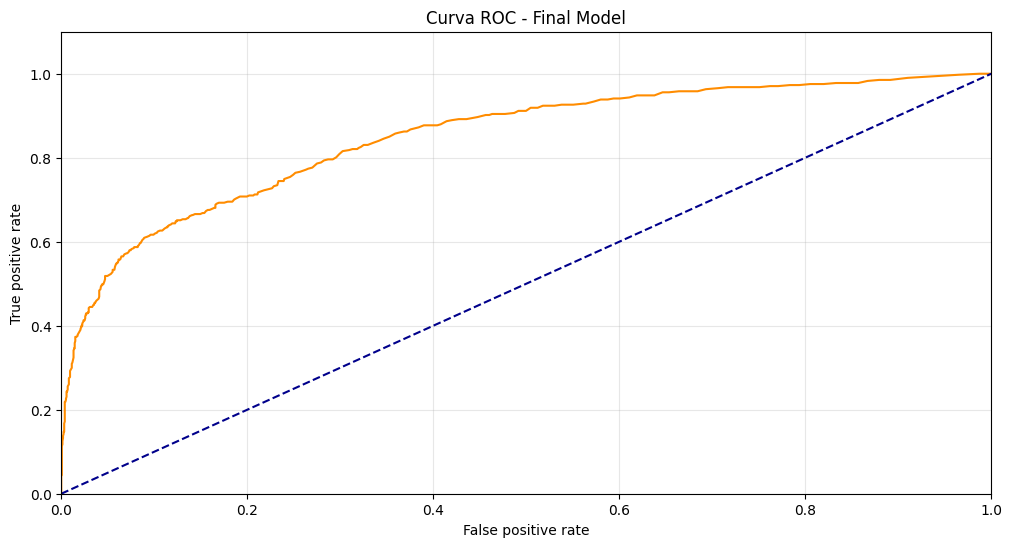

In [23]:
best_model = rf_random.best_estimator_

final_preds = best_model.predict(x_test)
final_probs = best_model.predict_proba(x_test)[:, 1]

final_f1 = f1_score(y_test, final_preds)
final_roc_auc = roc_auc_score(y_test, final_probs)

print("F1-Score FINAL:", final_f1)
print("AUC-ROC FINAL: ", final_roc_auc)

#Plotting the curve
fpr, tpr, threshold = roc_curve(y_test, final_probs)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {final_roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Curva ROC - Final Model")
plt.grid(alpha=0.3)
plt.show()

The ROC curve demonstrates the model’s ability to distinguish between customers who will churn and those who will remain. The AUC-ROC value obtained indicates good discriminatory power between the classes.

Comparing this with the FINAL F1-score, we can see that, although the model performs well in classification, the F1-score revealed a more realistic balance between precision and recall for the minority class—that is, customers who churn.

This reinforces the importance of using multiple metrics. While the AUC-ROC assesses the overall quality of the model, the F1-score is more sensitive to performance in the class of interest, which in this case is predicting customer churn.

### Conclusion for BETA BANK
The main objective of this project was to create a predictive tool to prevent ongoing customer churn, since retention is more cost-effective than acquisition. 

Through rigorous data cleaning, handling class imbalance, and hyperparameter optimization, I have delivered a robust solution. Beta Bank now has a reliable machine learning model, ready to identify customers at risk of churn. With this, bankers can act proactively, targeting loyalty campaigns and personalized offers specifically at the customers who need them, thereby optimizing operational costs.